# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

### **Section 0: Preparation**

In [1]:
# テンソルを見やすく表示する関数
import torch
import torch.nn as nn
import torch.nn.functional as F

# テンソルを見やすく表示するライブラリをインストール
!pip install git+https://github.com/HayatoHongo/print_formatted_tensor.git
# Pytorchのテンソルを見やすく表示する関数をインポート
from torch_print_tensor import print_formatted_tensor


  Cloning https://github.com/HayatoHongo/print_formatted_tensor.git to /tmp/pip-req-build-9vqin824
  Running command git clone --filter=blob:none --quiet https://github.com/HayatoHongo/print_formatted_tensor.git /tmp/pip-req-build-9vqin824
  Resolved https://github.com/HayatoHongo/print_formatted_tensor.git to commit f49215af7fa16f6b59af210897f472d421137dd4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for torch_print_tensor: filename=torch_print_tensor-0.0.0-py3-none-any.whl size=1775 sha256=15d7cc915451ab77acec99ffc35b66c0e89180bdb9b9b6b25e7b9ec1bf6b14cd
  Stored in directory: /tmp/pip-ephem-wheel-cache-0smn_h98/wheels/42/f2/8a/de376763a7e40db1b6011a73df3f759a5d4cdaf6278ffb8a4e
Successfully built torch_print_tensor


# **Chapter 25: LR schedule**

### **Section 1: 学習率を計算する関数を定義する**
CODE: `def get_learning_rate(current_step, config)`

**Mission: 現在のステップ数に応じた、適切な学習率を計算する！**

学習率をずっと一定にすると、学習の序盤に更新が大きくなりすぎて学習が不安定になることがあります。    
また、モデルの学習が進んでいくにつれ、パラメータは意味があるものとなるため、慎重にパラメータを更新します。  
そこで、最初は学習率を小さく始めて、徐々に上げたり（warmup）、徐々に下げたり（decay）します。

- 前半: 0 → `max_learning_rate` まで直線的に上げる（Linear Warmup）
- 後半: `max_learning_rate` → `min_learning_rate` に向けて直線的に下げる（Linear Decay）


**設定例：**

* **最大学習率**: `1e-3` / **最小学習率**: `1e-4`
* **全体**: `10,000` ステップ / **ウォームアップ**: `1,000` ステップ

この構成により、最初の 1,000 ステップで山を登り、残りの 9,000 ステップでふもとへ向かって緩やかに下るスケジュールが完成します。


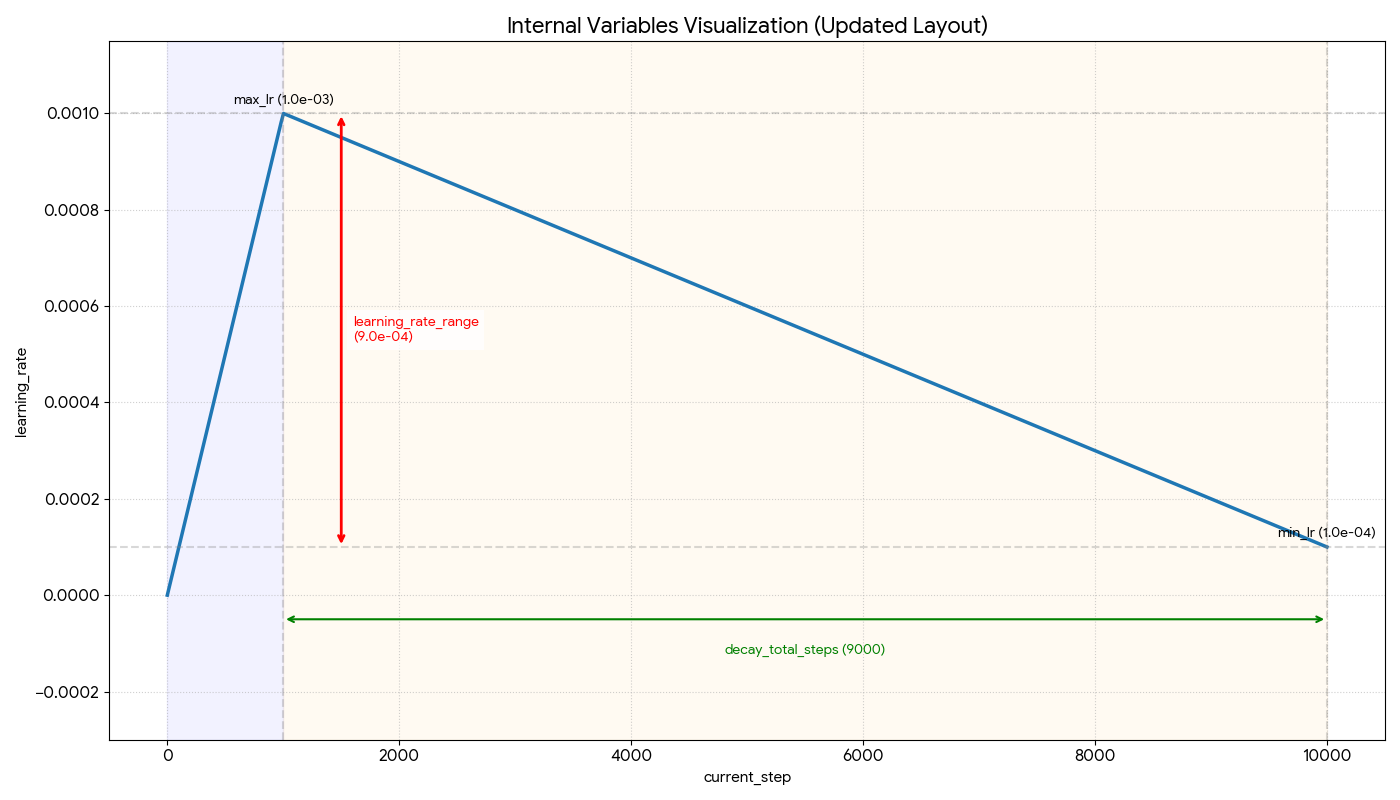

In [2]:
class Config:
    max_learning_rate = 1e-3
    min_learning_rate = 1e-4
    warmup_steps = 1_000
    total_training_steps = 10_000

In [3]:
config = Config()

In [4]:
max_learning_rate = config.max_learning_rate
print("max_learning_rate", max_learning_rate)

max_learning_rate 0.001


**`Check Point`** <label><input type="checkbox">max_learning_rate 0.001</label>

In [5]:
min_learning_rate = config.min_learning_rate
print("min_learning_rate", min_learning_rate)

min_learning_rate 0.0001


**`Check Point`** <label><input type="checkbox">min_learning_rate 0.0001</label>

In [6]:
warmup_steps = config.warmup_steps
print("warmup_steps", warmup_steps)

warmup_steps 1000


**`Check Point`** <label><input type="checkbox">warmup_steps 1000</label>

In [7]:
total_training_steps = config.total_training_steps
print("total_training_steps", total_training_steps)

total_training_steps 10000


**`Check Point`** <label><input type="checkbox">total_training_steps 10000</label>

#### ▼ 直線ウォーミングアップ段階のケースのサンプル値

In [8]:
# 直線ウォーミングアップ段階でのサンプル値
current_step = 500

#### **現在の学習ステップが、線形ウォーミングアップ段階にある場合**
CODE: `if current_step < warmup_steps:`

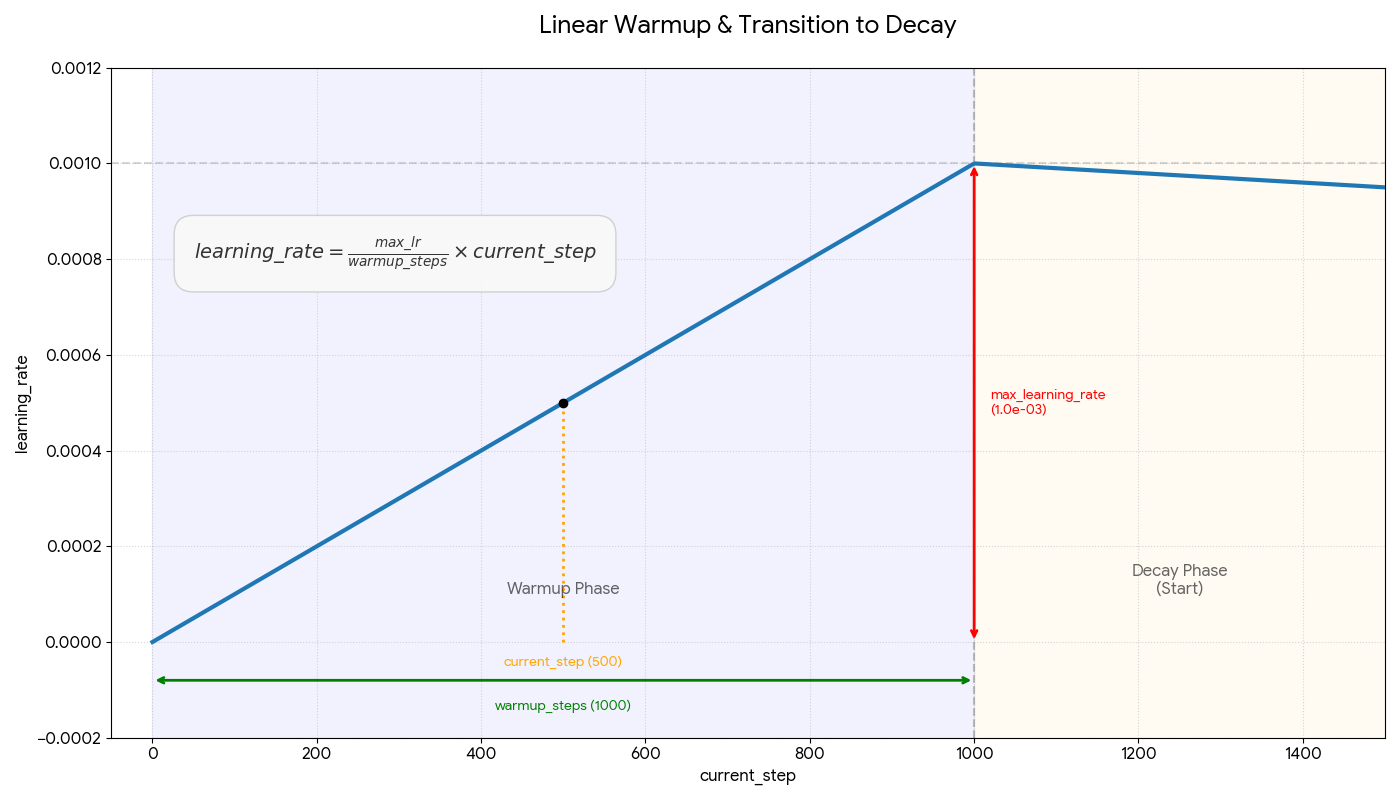

**Mission: ウォームアップフェーズの計算**

学習初期の不安定な勾配による影響を抑えるため、学習率を $0$ から $max\_learning\_rate$ まで直線的に増加させます。

* **ステップ 1：1歩あたりの増加幅（傾き）を求める**     
最大学習率をウォームアップ期間の全ステップ数で割り、$slope$ を算出します。

$$slope = \frac{max\_learning\_rate}{warmup\_steps}$$


* **ステップ 2：現在の学習率を算出する**    
現在のステップ数に $slope$ を掛け合わせます。

$$current\_learning\_rate = slope \times current\_step$$

例えば `current_step=500` はウォームアップの半分なので、学習率も **maxの半分**になります（この後のprintで確認します）。

```python
出力: slope（ウォームアップでの1ステップあたりの増加量）
式: THINK_BY_YOURSELF
```
- 最大学習率をウォームアップのステップ数で割り、1ステップぶんの増加量を求める。

In [ ]:
slope =  # TODO: 出力 = 式
print("slope", slope)

slope 1e-06


**`Check Point`** <label><input type="checkbox">slope 1e-06<label>

```python
出力: current_learning_rate（現在の学習率）
式: THINK_BY_YOURSELF
```
- 1ステップあたりの増加量 `slope` に、現在ステップ数 `current_step` を掛ける。

In [ ]:
current_learning_rate =  # TODO: 出力 = 式
print("current_learning_rate", current_learning_rate)

current_learning_rate 0.0005


**`Check Point`** <label><input type="checkbox">current_learning_rate 0.0005<label>

### **Section 2: 現在の学習ステップが、直線減衰段階にある場合**
CODE: `else:`

▼ 直線減衰段階のケースのサンプル値

In [ ]:
current_step = 5500

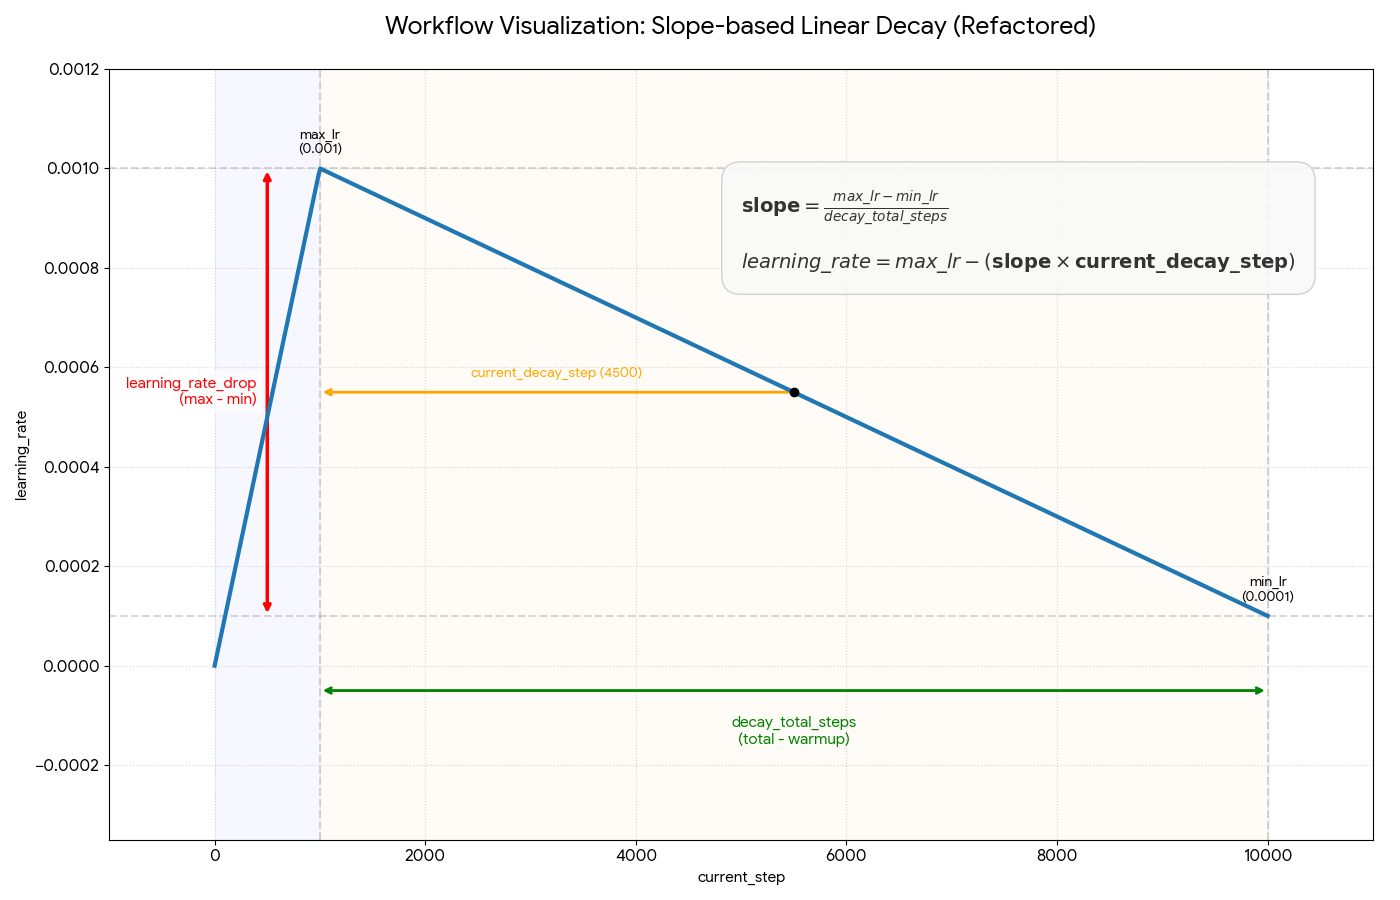

**Mission 線形減衰フェーズの学習率を計算する**

ウォームアップ終了後、学習率を $max\_learning\_rate$ から $min\_learning\_rate$ へ向かって一定の傾斜で下げていきます。

* **ステップ 1：現在地の特定**  
減衰開始地点からの経過歩数 $decay\_current\_step$ を求めます。

$$decay\_current\_step = current\_step - warmup\_steps$$


* **ステップ 2：傾き（1歩あたりの削り量）の算出**   
減衰させる総量を、残りの全ステップ数で割り、$slope$ を算出します。

$$slope = \frac{max\_learning\_rate - min\_learning\_rate}{total\_training\_steps - warmup\_steps}$$


* **ステップ 3：学習率の算出**  
最大値から「削り量 $\times$ 歩数」を差し引きます。

$$learning\_rate = max\_learning\_rate - (slope \times decay\_current\_step)$$

```python
出力: current_decay_step（減衰区間での経過ステップ数）
式: THINK_BY_YOURSELF
```
- 全体のステップからウォームアップ分を引き、減衰区間でどこまで進んだかを求める。

In [ ]:
current_decay_step =  # TODO: 出力 = 式
print("current_decay_step", current_decay_step)

current_decay_step 4500


**`Check Point`** <label><input type="checkbox">current_decay_step 4500<label>

```python
出力: decay_total_steps（減衰に使う総ステップ数）
式: THINK_BY_YOURSELF
```
- 総学習ステップからウォームアップ分を引き、減衰の長さを求める。

In [ ]:
decay_total_steps =  # TODO: 出力 = 式
print("decay_total_steps", decay_total_steps)

decay_total_steps 9000


**`Check Point`** <label><input type="checkbox">decay_total_steps 9000<label>

```python
出力: learning_rate_drop（学習率の下げ幅）
式: THINK_BY_YOURSELF
```
- 最大値と最小値の差分を取り、減衰でどれだけ下げるかを求める。

In [ ]:
learning_rate_drop =  # TODO: 出力 = 式
print("learning_rate_drop", learning_rate_drop)

learning_rate_drop 0.0009


**`Check Point`** <label><input type="checkbox">learning_rate_drop 0.0009<label>

```python
出力: slope（減衰区間での1ステップあたりの下落幅）
式: THINK_BY_YOURSELF
```
- 下げ幅を減衰ステップ数で割り、1ステップあたりの下落幅を求める。

In [ ]:
slope =  # TODO: 出力 = 式
print("slope", slope)

slope 1e-07


**`Check Point`** <label><input type="checkbox">slope 1e-07<label>

```python
出力: current_learning_rate（現在の学習率）
式: THINK_BY_YOURSELF
```
- 最大値から、減衰区間で進んだ分（下落幅×経過ステップ）を引く。

In [ ]:
current_learning_rate =  # TODO: 出力 = 式
print("current_learning_rate", current_learning_rate)

current_learning_rate 0.00055


**`Check Point`** <label><input type="checkbox">current_learning_rate 0.00055<label>

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`config`　`warmup_steps`　`current_step`　`current_learning_rate`　`slope`　`current_decay_step`　`decay_total_steps`　`learning_rate_drop`　`learning_rate`　`decay_step_index`

In [ ]:
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_training_steps = config.total_training_steps

    if current_step < _________:  # TODO: FILL
        # --- Linear Warmup ---
        # 「1ステップあたりの上昇幅（傾き）」を求める
        slope = max_learning_rate / ___________  # TODO: FILL
        current_learning_rate = ___________ * current_step  # TODO: FILL

    else:
        # --- Linear Decay ---
        # 1. 減衰区間での「現在地」を特定する
        current_decay_step = current_step - ___________  # TODO: FILL

        # 2. 「1ステップあたりの下落幅（傾き）」を求める
        decay_total_steps = ________________ - warmup_steps  # TODO: FILL
        learning_rate_drop = max_learning_rate - ________________  # TODO: FILL
        slope = learning_rate_drop / ______________  # TODO: FILL

        # 3. 現在の学習率を算出する (最大値から、進んだ分だけ削る)
        current_learning_rate = max_learning_rate - (slope * ___________________)  # TODO: FILL

    return current_learning_rate

<details>
<summary>クリックして答えを表示/非表示する</summary>

```python
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_training_steps = config.total_training_steps

    if current_step < warmup_steps:
        # --- Linear Warmup ---
        # 「1ステップあたりの上昇幅（傾き）」を求める
        slope = max_learning_rate / warmup_steps
        current_learning_rate = slope * current_step

    else:
        # --- Linear Decay ---
        # 1. 減衰区間での「現在地」を特定する
        current_decay_step = current_step - warmup_steps
        
        # 2. 「1ステップあたりの下落幅（傾き）」を求める
        decay_total_steps = total_training_steps - warmup_steps
        learning_rate_drop = max_learning_rate - min_learning_rate
        slope = learning_rate_drop / decay_total_steps

        # 3. 現在の学習率を算出する (最大値から、進んだ分だけ削る)
        current_learning_rate = max_learning_rate - (slope * current_decay_step)

    return current_learning_rate
```

</details>

### **Section 3: Trainerクラスの更新**

`TinyStories`のデータをダウンロードしましょう。<br>
高速化のため、hf_hub_downloadを用います。

In [3]:
from huggingface_hub import hf_hub_download
hf_hub_download(
    repo_id="HayatoHongo/TinyStories_npy",
    repo_type="dataset",
    filename="TinyStories-train.npy",
    local_dir=".",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


TinyStories-train.npy:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

'TinyStories-train.npy'

DataLoaderに変更はありません。

In [4]:
import torch
import numpy as np
import tiktoken

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）

        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab

        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")

        # 訓練・検証用データの範囲を決める（実データは共有）
        self.train_data, self.val_data = self.split_data()

    def split_data(self):
        # データを 90%:10% に分割し、インデックス範囲で保持
        split_index = int(0.9 * len(self.data))
        return (0, split_index), (split_index, len(self.data))

    def get_batch(self, split):

        # 指定された split ('train' or 'val') からランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。

        # splitに応じたデータ範囲を取得
        range_start, range_end = (
            self.train_data if split == 'train' else self.val_data
        )

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

モデルクラスに変更はありません。

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)

class RelativePositionEmbedding(nn.Module):
    def __init__(self, num_relative_positions: int):
        super().__init__()
        self.num_relative_positions = num_relative_positions
        self.bias_embedding_table = nn.Embedding(self.num_relative_positions, 1)

    def forward(self, query_len, key_len, device_type=None):
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (query_len, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, key_len)
        relative_position_matrix = query_positions - key_positions # key_positions - query_positions

        # 相対距離を範囲 [0, max_distance - 1] に収める（負の距離や過大距離を切り詰め）
        # (query_len, key_len)
        clamped_relative_position_matrix = relative_position_matrix.clamp(
            min=0, max=self.num_relative_positions - 1
        )

        # 埋め込み層から対応するバイアスベクトルを取得
        # (query_len, key_len, 1)
        relative_position_bias_embeddings = self.bias_embedding_table(clamped_relative_position_matrix)

        # 最後の次元を除去して行列化
        # (query_len, key_len)
        relative_position_bias_matrix = relative_position_bias_embeddings.squeeze(-1)

        return relative_position_bias_matrix


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        # ドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)
        self.head_size = head_size
        self.relative_position_embedding_layer = RelativePositionEmbedding(num_relative_positions=config.num_relative_positions)

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # 相対位置バイアスの補正項を計算する
        relative_position_bias_matrix = self.relative_position_embedding_layer(T, T, device_type=input_tensor.device)

        # 相対位置バイアスの補正項を加算する
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)
        attention_weights = self.dropout(attention_weights)

        out = attention_weights @ Value  # (B, T, head_size)
        return out

class nanoGPT(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        token_embeddings = self.token_embedding_layer.embed(input_indices)
        blocks_output = self.blocks(token_embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens, temperature=1.0):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            last_logits = last_logits / temperature
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)

        # 出力のドロップアウト
        self.dropout = nn.Dropout(config.dropout_rate)

    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        # 最終出力にドロップアウトを適用する
        output = self.dropout.forward(projected)

        return output

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
            nn.Dropout(config.dropout_rate),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits

`max_learning_rate`,`min_learning_rate`, `warmup_steps` について、Configクラスに反映します。

なお、今回は時間短縮のため、`total_training_steps`を10,000ではなく、2,000とします。

In [6]:
# モデル設定を保存する設定クラス
class Config:
    batch_size = 16
    input_sequence_length = 512
    ########## NEW ##########
    max_learning_rate = 1e-3
    min_learning_rate = 1e-4
    warmup_steps = 1_000
    ########## NEW ##########

    ########## NEW ##########
    total_training_steps = 2_000  # おおよそ13分
    ########## NEW ##########

    device_type = 'cuda'  # 使用デバイスはGPUに固定する
    evaluation_frequency = 100  # モデル性能評価の頻度
    """DELETE
    learning_rate = 2e-3  # 学習率
    """
    evaluation_loops = 10  # 評価中の繰り返し回数
    embedding_dim = 256  # 埋め込み次元数
    hidden_dim = 1024
    num_attention_heads = 4  # アテンションヘッドの数
    layer_count = 4  # モデルの層数
    num_relative_positions = 128 # 相対位置が考慮する範囲
    dropout_rate = 0.1  # ドロップアウト確率
    random_seed_value = 1337  # 再現性のための乱数シード

In [7]:
# 設定を読み込みシードを設定する
config = Config()
torch.manual_seed(config.random_seed_value)  # 再現性確保のため乱数シードを設定

Dataloaderインスタンスを作成してください。


In [ ]:
data_loader =  # TODO: インスタンス = クラス(引数)

In [30]:
model = nanoGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type)

今回は固定の学習率がないので、optimizerインスタンスを作成する時に省略します。

```python
インスタンス: optimizer（学習時にモデルのパラメータを更新する最適化器）
クラス: torch.optim.AdamW（Adam + Weight Decay を行う最適化アルゴリズム）
引数: model.parameters()（更新対象にするモデルの全パラメータ）
```
- `lr` を省略するとデフォルトの学習率が使われます。

In [ ]:
# 学習率を指定せずに、optimizerインスタンスを作成します。
"""DELETE
optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
"""
optimizer =  # TODO: インスタンス = クラス(引数)

`optimizer` の中には、更新するパラメータのグループを並べた **`param_groups` というリスト** があります。   
今回は`model.parameters()` を丸ごと渡しているため、パラメータのグループは **1つだけ** です。  
そのため、`param_groups[0]` を見るだけで、全パラメータの設定をカバーできます。  
現在の学習率は、**`optimizer.param_groups[0]["lr"]`** で一発で取得・更新が可能です。    

In [ ]:
print(optimizer.param_groups[0]["lr"])

0.001


デフォルトの学習率である0.001が表示されているはずです。

ここで、あるサンプル値として現在のステップ数が500だったとして、optimizerインスタンスの学習率をアップデートしてみます。

In [ ]:
current_step = 500

In [ ]:
optimizer.param_groups[0]["lr"] = get_learning_rate(current_step, config)
print(optimizer.param_groups[0]["lr"])

0.0005


ここまでを踏まえて、Trainerクラスに変更を加えます。

🔘 **Options**: 余計な選択肢があるかもしれません。同じ選択肢を2回以上使うかもしれません。

`get_learning_rate`　`current_learning_rate`　`optimizer`　`param_groups`　`step`　`learning_rate`　`max_learning_rate`　`min_learning_rate`　`warmup_steps`　`total_training_steps`　`train_loss`　`eval_loss`　`learning_rates`　`append`　`self`

In [ ]:
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        ########## NEW ##########
        self.learning_rates = []
        ########## NEW ##########
        self.train_losses = []
        self.val_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.config.total_training_steps+1):
            ########## NEW ##########
            # これまでは毎ステップ行う処理を評価後に行ってきましたが、可読性向上のため、評価前に行うことにします。
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = __________________(____, self.config)  # TODO: FILL
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()
            ########## NEW ##########

            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == 0:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
                ########## NEW ##########
                current_learning_rate = ____________________  # TODO: FILL
                ########## NEW ##########

                print(
                    f"step {step:05d} | ",
                    ########## NEW ##########
                    f"lr {____________________:.6e} | ",  # TODO: FILL
                    ########## NEW ##########
                    f"train loss {eval_loss['train']:.4f} | ",
                    f"val loss {eval_loss['val']:.4f} | ",
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                    f"tokens {total_seen_tokens:,} | ",
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                ########## NEW ##########
                self.learning_rates.append(____________________)  # TODO: FILL
                ########## NEW ##########
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                self.tokens_per_second_list.append(tokens_per_second)
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()

            """DELETE
            # 1回の学習ステップ（毎回行う主な処理）
            train_loss = self.train_step()
            """

<details>
<summary>クリックして答えを表示/非表示する</summary>

```python
import time

class Trainer:
    def __init__(self, model, optimizer, data_loader, config):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config

        self.steps = []
        ########## NEW ##########
        self.learning_rates = []
        ########## NEW ##########
        self.train_losses = []
        self.val_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch('train')
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算
        logits, loss = self.model(input_batch, target_batch)
        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def evaluate(self):
        self.model.eval()  # 評価モードに切り替え
        losses = {"train": [], "val": []} # 学習・検証データ両方の損失を計算
        with torch.no_grad():
            for split in ['train', 'val']:
                for _ in range(self.config.evaluation_loops):
                    input_batch, target_batch = self.data_loader.get_batch(split)
                    _, loss = self.model(input_batch, target_batch)
                    losses[split].append(loss.item())
        self.model.train()  # 再び学習モードへ戻す

        # 各データセット（train, val）での損失の平均を計算して返す
        return {split: sum(values) / len(values) for split, values in losses.items()}

    def train(self):
        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.config.total_training_steps+1):
            ########## NEW ##########
            # これまでは毎ステップ行う処理を評価後に行ってきましたが、可読性向上のため、評価前に行うことにします。
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()
            ########## NEW ##########

            # 100回ごとに評価する。
            if step % self.config.evaluation_frequency == 0:
                if step == 0:
                  tokens_per_second = None
                  total_train_time = 0
                else:
                  current_eval_start_time = time.time()
                  evaluation_interval = current_eval_start_time - last_eval_end_time
                  total_train_time += evaluation_interval
                  tokens_per_evaluation_interval = self.config.batch_size * self.config.input_sequence_length * self.config.evaluation_frequency
                  tokens_per_second = tokens_per_evaluation_interval / evaluation_interval

                eval_loss = self.evaluate()
                total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
                ########## NEW ##########
                current_learning_rate = self.optimizer.param_groups[0]["lr"]
                ########## NEW ##########

                print(
                    f"step {step:05d} | ",
                    ########## NEW ##########
                    f"lr {current_learning_rate:.6e} | ",
                    ########## NEW ##########
                    f"train loss {eval_loss['train']:.4f} | ",
                    f"val loss {eval_loss['val']:.4f} | ",
                    f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                    f"tokens {total_seen_tokens:,} | ",
                    f"time {total_train_time:.2f}s"
                )

                self.steps.append(step)
                ########## NEW ##########
                self.learning_rates.append(current_learning_rate)
                ########## NEW ##########
                self.train_losses.append(eval_loss['train'])
                self.val_losses.append(eval_loss['val'])
                self.tokens_per_second_list.append(tokens_per_second)
                self.total_seen_tokens_list.append(total_seen_tokens)
                self.total_train_time_list.append(total_train_time)

                # この評価が終わった時間を記録する。次の評価開始時との時間差が`evaluation_interval`となる。
                last_eval_end_time = time.time()

            """DELETE
            # 1回の学習ステップ（毎回行う主な処理）
            train_loss = self.train_step()
            """
```

</details>

### **Section 4. モデルの学習**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: User cancelled dfs_ephemeral authorization

### 🚀 学習スタート！

今回は **15 GB RAM の T4 GPU** を使用し、
`batch size = 16`、`total steps = 2,000` の設定で進めます。

T4 GPUの場合、およそ13分かかります。



In [ ]:
optimizer2 =  # TODO: インスタンス = クラス(引数)

In [33]:
print("===トレーニングが正常に開始されました===")

# モデルを学習する
trainer = Trainer(model, optimizer2, data_loader, config)
trainer.train()

===トレーニングが正常に開始されました===
step 00000 |  lr 0.000000e+00 |  train loss 10.9807 |  val loss 10.9806 |  tok/s None |  tokens 0 |  time 0.00s
step 00100 |  lr 1.000000e-04 |  train loss 7.7389 |  val loss 7.7227 |  tok/s 23670 |  tokens 819,200 |  time 34.61s
step 00200 |  lr 2.000000e-04 |  train loss 5.2910 |  val loss 5.2683 |  tok/s 22875 |  tokens 1,638,400 |  time 70.42s
step 00300 |  lr 3.000000e-04 |  train loss 4.4730 |  val loss 4.5310 |  tok/s 22345 |  tokens 2,457,600 |  time 107.08s
step 00400 |  lr 4.000000e-04 |  train loss 4.1519 |  val loss 4.1275 |  tok/s 21841 |  tokens 3,276,800 |  time 144.59s
step 00500 |  lr 5.000000e-04 |  train loss 3.9602 |  val loss 3.8972 |  tok/s 21437 |  tokens 4,096,000 |  time 182.80s
step 00600 |  lr 6.000000e-04 |  train loss 3.7422 |  val loss 3.7491 |  tok/s 21235 |  tokens 4,915,200 |  time 221.38s
step 00700 |  lr 7.000000e-04 |  train loss 3.6092 |  val loss 3.6387 |  tok/s 21265 |  tokens 5,734,400 |  time 259.90s
step 00800 |  lr 8.00

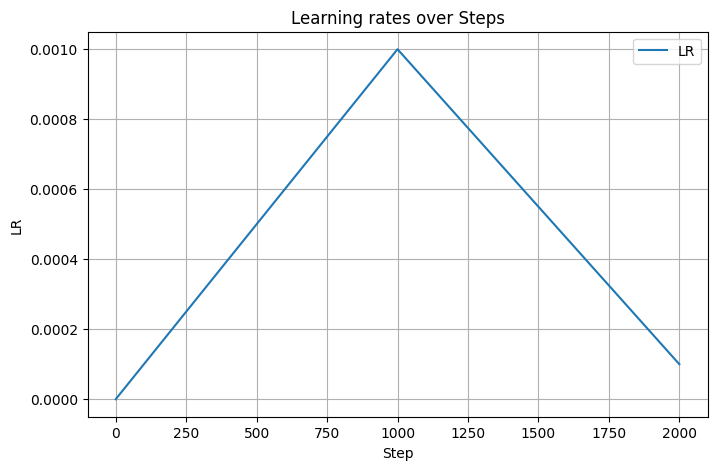

In [18]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.learning_rates, label='LR')
plt.xlabel('Step')
plt.ylabel('LR')
plt.title('Learning rates over Steps')
plt.legend()
plt.grid(True)
plt.show()

ここで、学習率を5e-4に固定した場合のログを以下に追記します。

学習率スケジューラを用いた場合でも、学習率を5e-4に固定した場合でも、2,000stepにおけるlossはほとんど変わらないことが分かります。

学習率スケジュールは学習効率に対してほとんど悪影響を与えることなく、学習を安定化させることができるので、一般的に広く用いられています。

```
===トレーニングが正常に開始されました===
step 00000 |  lr 5.000000e-04 |  train loss 10.4028 |  val loss 10.4015 |  tok/s None |  tokens 0 |  time 0.00s
step 00100 |  lr 5.000000e-04 |  train loss 4.4979 |  val loss 4.4818 |  tok/s 23059 |  tokens 819,200 |  time 35.53s
step 00200 |  lr 5.000000e-04 |  train loss 4.0114 |  val loss 4.0098 |  tok/s 22384 |  tokens 1,638,400 |  time 72.12s
step 00300 |  lr 5.000000e-04 |  train loss 3.8132 |  val loss 3.8176 |  tok/s 21906 |  tokens 2,457,600 |  time 109.52s
step 00400 |  lr 5.000000e-04 |  train loss 3.7057 |  val loss 3.7386 |  tok/s 21467 |  tokens 3,276,800 |  time 147.68s
step 00500 |  lr 5.000000e-04 |  train loss 3.5748 |  val loss 3.6021 |  tok/s 21232 |  tokens 4,096,000 |  time 186.26s
step 00600 |  lr 5.000000e-04 |  train loss 3.5001 |  val loss 3.5170 |  tok/s 21265 |  tokens 4,915,200 |  time 224.78s
step 00700 |  lr 5.000000e-04 |  train loss 3.4256 |  val loss 3.4502 |  tok/s 21238 |  tokens 5,734,400 |  time 263.35s
step 00800 |  lr 5.000000e-04 |  train loss 3.3146 |  val loss 3.3280 |  tok/s 21263 |  tokens 6,553,600 |  time 301.88s
step 00900 |  lr 5.000000e-04 |  train loss 3.2542 |  val loss 3.1879 |  tok/s 21255 |  tokens 7,372,800 |  time 340.42s
step 01000 |  lr 5.000000e-04 |  train loss 3.1019 |  val loss 3.0886 |  tok/s 21252 |  tokens 8,192,000 |  time 378.97s
step 01100 |  lr 5.000000e-04 |  train loss 3.0965 |  val loss 3.0748 |  tok/s 21273 |  tokens 9,011,200 |  time 417.47s
step 01200 |  lr 5.000000e-04 |  train loss 3.0298 |  val loss 2.9768 |  tok/s 21243 |  tokens 9,830,400 |  time 456.04s
step 01300 |  lr 5.000000e-04 |  train loss 2.9673 |  val loss 2.9498 |  tok/s 21262 |  tokens 10,649,600 |  time 494.56s
step 01400 |  lr 5.000000e-04 |  train loss 2.9197 |  val loss 2.8673 |  tok/s 21261 |  tokens 11,468,800 |  time 533.09s
step 01500 |  lr 5.000000e-04 |  train loss 2.8416 |  val loss 2.8880 |  tok/s 21243 |  tokens 12,288,000 |  time 571.66s
step 01600 |  lr 5.000000e-04 |  train loss 2.8530 |  val loss 2.8185 |  tok/s 21272 |  tokens 13,107,200 |  time 610.17s
step 01700 |  lr 5.000000e-04 |  train loss 2.8199 |  val loss 2.7679 |  tok/s 21246 |  tokens 13,926,400 |  time 648.72s
step 01800 |  lr 5.000000e-04 |  train loss 2.7148 |  val loss 2.7055 |  tok/s 21262 |  tokens 14,745,600 |  time 687.25s
step 01900 |  lr 5.000000e-04 |  train loss 2.6463 |  val loss 2.6643 |  tok/s 21264 |  tokens 15,564,800 |  time 725.78s
step 02000 |  lr 5.000000e-04 |  train loss 2.6634 |  val loss 2.6862 |  tok/s 21247 |  tokens 16,384,000 |  time 764.33s
```

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 24: Relative Position Embedding(Simplified)** <label><input type="checkbox"> Mark as Done</label>